<a href="https://colab.research.google.com/github/biswal-prem-5677/Coding-Journey/blob/main/ai/02_machine_learning/experiment_ml_classification_and_clustering_model_comparison_iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SVM: 1.0000
KNN: 1.0000
Decision Tree: 1.0000
Random Forest: 1.0000
XGBoost: 1.0000


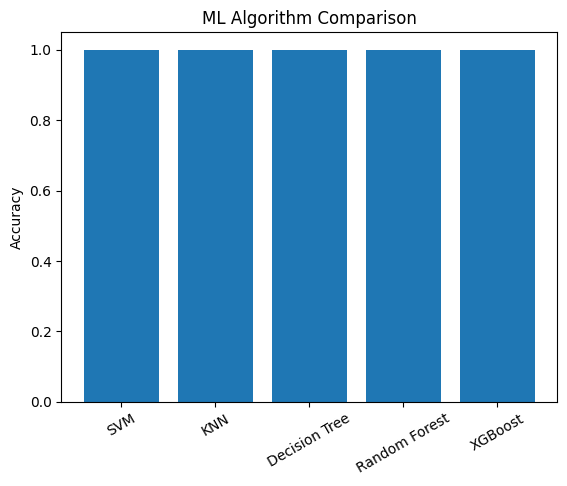

In [ ]:
# ============================================
# CLASSICAL ML COMPARISON SYSTEM
# ============================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# -------------------------------
# 1. Load Data
# -------------------------------
data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 2. Models
# -------------------------------
models = {
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='mlogloss')
}

# -------------------------------
# 3. Train + Evaluate
# -------------------------------
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)

    results[name] = acc

    print(f"{name}: {acc:.4f}")

# -------------------------------
# 4. Visualization
# -------------------------------
names = list(results.keys())
accuracies = list(results.values())

plt.figure()
plt.bar(names, accuracies)
plt.title("ML Algorithm Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

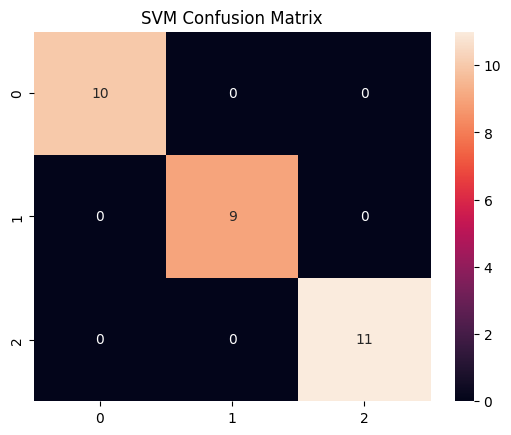

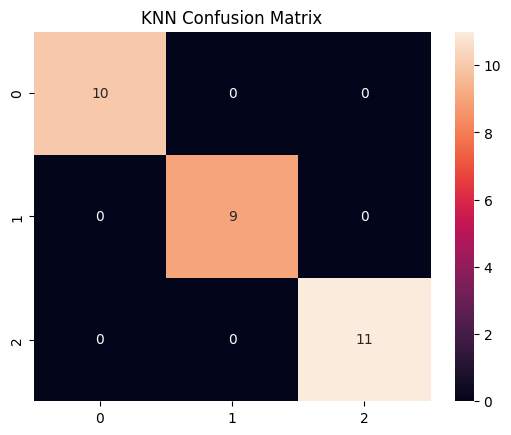

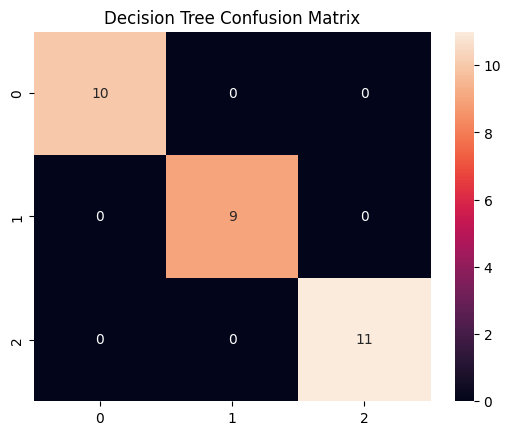

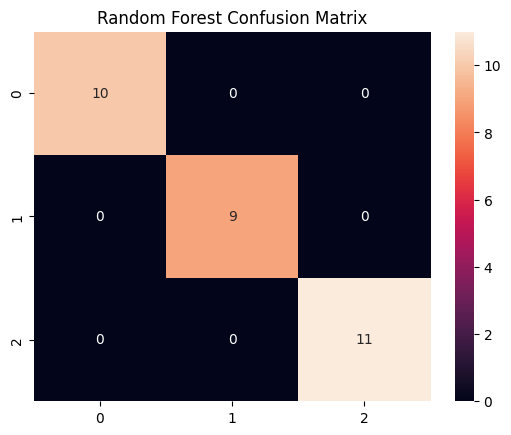

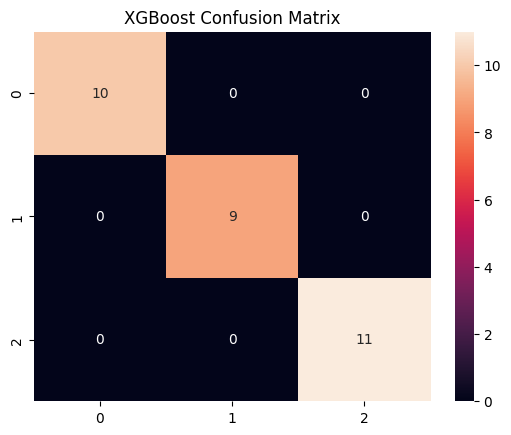

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

for name, model in models.items():
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [ ]:
# ============================================
# CLUSTERING (UNSUPERVISED LEARNING)
# ============================================

from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score

# -------------------------------
# 1. Models
# -------------------------------
clustering_models = {
    "KMeans": KMeans(n_clusters=3, random_state=42),
    "DBSCAN": DBSCAN(eps=0.5)
}

# -------------------------------
# 2. Train + Evaluate
# -------------------------------
cluster_results = {}

for name, model in clustering_models.items():

    labels = model.fit_predict(X)

    # Compare with true labels (evaluation trick)
    score = adjusted_rand_score(y, labels)

    cluster_results[name] = score

    print(f"{name} Score (ARI): {score:.4f}")

KMeans Score (ARI): 0.7163
DBSCAN Score (ARI): 0.5206


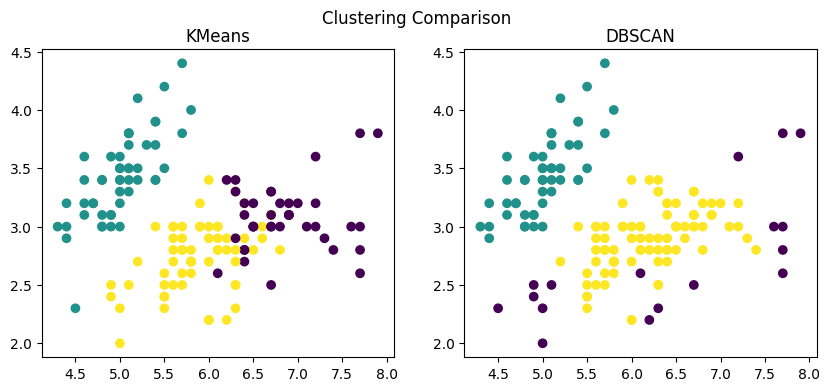

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i, (name, model) in enumerate(clustering_models.items()):
    labels = model.fit_predict(X)

    plt.subplot(1,2,i+1)
    plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
    plt.title(name)

plt.suptitle("Clustering Comparison")
plt.show()

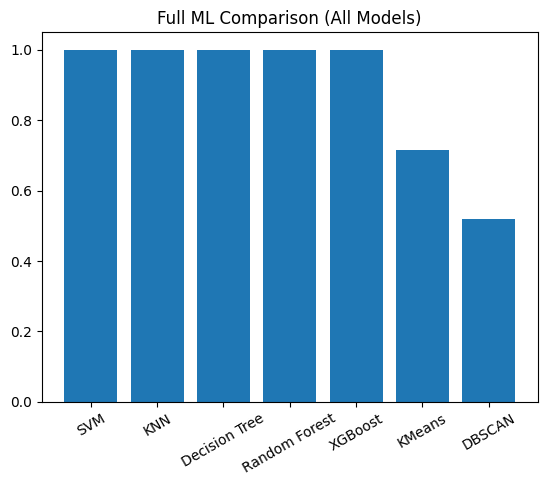

In [ ]:
# Combine supervised + unsupervised results

all_names = list(results.keys()) + list(cluster_results.keys())
all_scores = list(results.values()) + list(cluster_results.values())

plt.figure()
plt.bar(all_names, all_scores)
plt.title("Full ML Comparison (All Models)")
plt.xticks(rotation=30)
plt.show()